## Initialisation du Retriever 
### Tous les paramètres sont initialisés dans le .yaml de configuration
#### Un logger "correct" permet de suivre quelques étapes

In [1]:

from backend.RagCore.Retrieving.retriever import RAGRetriever
retriever = RAGRetriever()


INFO: Toutes les variables d'environnement requises sont chargées
INFO: Using ChromaDB path: /Users/mtis/Local/Code/GitRepos/LangAI/data/chromaDB
INFO: Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
/Users/mtis/Local/Code/GitRepos/LangAI/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO: Load pretrained SentenceTransformer: antoinelouis/french-gte-multilingual-base
INFO: Evaluation mode enabled
INFO: RAGRetriever initialized.


#### Pour vérifier si la base vectorielle est opérationnelle (non vide)

In [2]:
all_data = retriever.chroma.get(
    include=["documents", "metadatas", "embeddings"]
)

num_docs = len(all_data["documents"])
print(f"Collection contains {num_docs} documents")

for doc, meta in zip(all_data["documents"], all_data["metadatas"]):
    print(f" • {doc[:5]}…  — metadata: {meta}")

Collection contains 24 documents
 • M. Gu…  — metadata: {'id': '0605a9c9-891d-45de-9eac-10969777106b', 'source': '1881-01-20'}
 • .…  — metadata: {'id': '0deb9275-b8fd-4fdd-a306-7f04de9670a5', 'source': '1881-01-20'}
 • COIPT…  — metadata: {'id': '0df0ff9c-9d7b-4924-96fd-3581a4afaf91', 'source': '1881-01-20'}
 • M. Lo…  — metadata: {'id': '212e0501-90dd-46b0-b10a-aa015ea44530', 'source': '1881-01-20'}
 • SCRUT…  — metadata: {'id': '2380a9a6-3fc8-473d-955f-27f8de0833b8', 'source': '1881-01-20'}
 • 

HES…  — metadata: {'id': '32d0668b-15e1-4204-b744-2232ad54d8bd', 'source': '1881-01-20'}
 • M. Al…  — metadata: {'id': '5046b5b8-b0ad-468f-9e08-1123da5de465', 'source': '1881-01-20'}
 • M. le…  — metadata: {'id': '52ed50db-bb7a-49e5-8b68-b3eb50422c4f', 'source': '1881-01-20'}
 • 
M. l…  — metadata: {'id': '57bff860-fdab-4bbf-9105-e7d392b58280', 'source': '1881-01-20'}
 • M. le…  — metadata: {'id': '61ca65a1-4afe-4f8d-9542-26c90596044e', 'source': '1881-01-20'}
 • 
M. l…  — metadata: {'id': '

### Petit test initial du retriever pour vérifier que la séquence de récupération fonctionne entièrement

In [3]:
retriever.answer(question="combien de colons sont concernés par les indemnités")

INFO: Question posée : combien de colons sont concernés par les indemnités 
Batches: 100%|██████████| 1/1 [00:00<00:00, 11.39it/s]
INFO: → Retrieved 3 docs for: combien de colons sont concernés par les indemnités
INFO: Deduplicating 3 documents...
INFO: 3 unique documents retained.
Batches: 100%|██████████| 1/1 [00:00<00:00, 11.38it/s]
INFO: HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"


"D'après le contexte fourni, la pétition no 1855 concerne **quatre-vingt-douze colons** qui réclament des indemnités pour les dommages subis lors de l'insurrection des Canaques en Nouvelle-Calédonie. Le total des indemnités réclamées s'élevait à 2 450 810 francs 73, mais la sous-commission a réduit ce montant à 908 432 francs 55.\n\nAinsi, **92 colons** sont concernés par cette demande d'indemnités."

### Implémentation de "auto_eval" 
#### Fonction permettant de récupérer certaines métriques et informations à travers des QA successives

In [3]:
import json
from tqdm import tqdm
import time
import logging

# Setup logger
logger = logging.getLogger("auto_eval")
logger.setLevel(logging.INFO)
if not logger.hasHandlers():
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter("[%(asctime)s] [%(levelname)s] %(message)s"))
    logger.addHandler(h)

def auto_eval(
    retriever : RAGRetriever, 
    dataset_path: str, 
    target: str, 
    output_path: str = "results.json"
):
    """
    Évalue le RAG sur un fichier JSONL filtré par file_name.

    - rag        : instance de RAGRetriever
    - dataset_path    : chemin vers un .jsonl où chaque ligne est un JSON
    - target_file_name: on ne garde que les entrées dont entry["file_name"] == target_file_name
    - top_k      : nombre de docs à récupérer
    - output_path: où écrire les résultats agrégés
    """
    # Lecture du dataset
    with open(dataset_path, "r", encoding="utf-8") as f:
        data = [json.loads(line) for line in f if line.strip()]

    # Filtre par file_name on pourra trouver d'autre façons
    filtered = [e for e in data if target in e.get("file_name")]
    logger.info(f"{len(filtered)} questions pour '{target}'")

    results = []
    for entry in tqdm(filtered, desc="Évaluation"):
        question = entry["question"]
        # par défaut on part d'une info vide
        eval_info = {}
        try:
            answer = retriever.answer(question,entry.get("source"))
            # récupère les métriques stockées dans rag.eval_info
            eval_info = getattr(retriever, "eval_info", {}) or {}
        except Exception as e:
            logger.warning(f"Échec question [{question[:50]}…] — {e}")
            answer = "ERREUR: " + str(e)
            # même en cas d'erreur on garde eval_info vide


        results.append({
            "question": question,
            "expected_source": entry.get("source"),
            "answer": answer,
            "file_name": entry.get("file_name"),
            "expected_source_date": target,
            **eval_info
        })
        time.sleep(15)

    # On écrit le JSON final
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    logger.info(f"Résultats sauvegardés dans '{output_path}'")

### Auto eval prend en paramètre le chemin vers le fichier des questions x sources et en "target" la date (pour filtrer)
  Implémentation future, une target "none" voudra dire qu'on considère toutes les questions du fichier -> influence directement la façon de construire les collections (en particulier il faut une collection englobant toutes les séances)

In [4]:
auto_eval(retriever,dataset_path="data/questions_strat1.jsonl",target="1881-01-20")

INFO: 18 questions pour '1881-01-20'
Batches: 100%|██████████| 1/1 [00:00<00:00, 13.28it/s]
INFO: → Retrieved 3 docs for: Selon M. Cuneo d'Ornano, combien de fois la Chambre a-t-elle procédé à la constitution de son bureau ordinaire depuis novembre 1877?
INFO: Deduplicating 3 documents...
INFO: 3 unique documents retained.
Batches: 100%|██████████| 1/1 [00:00<00:00,  9.41it/s]
INFO: HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"
Batches: 100%|██████████| 1/1 [00:00<00:00, 14.21it/s]
INFO: → Retrieved 3 docs for: Selon M. Cuneo d'Ornano, pourquoi est-ce qu'il demande l'ajournement des scrutins pour la constitution du bureau?
INFO: Deduplicating 3 documents...
INFO: 3 unique documents retained.
Batches: 100%|██████████| 1/1 [00:00<00:00, 10.25it/s]
INFO: HTTP Request: POST https://api.mistral.ai/v1/chat/completions "HTTP/1.1 200 OK"
Batches: 100%|██████████| 1/1 [00:00<00:00, 17.80it/s]
INFO: → Retrieved 3 docs for: Quelle est la position de M. Cuneo d'Or

Fonction utilitaire pour fusionner des jsons (objectif créer un dataset unique)

In [5]:
import json
from typing import List

def concat_json_files(output: str, *input_files: List[str]):
    merged = []

    for path in input_files:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            if not isinstance(data, list):
                raise ValueError(f"Le fichier '{path}' ne contient pas une liste JSON au niveau supérieur.")
            merged.extend(data)

    with open(output, 'w', encoding='utf-8') as fout:
        json.dump(merged, fout, indent=2, ensure_ascii=False)

    print(f" {len(merged)} éléments sauvegardés dans '{output}' à partir de {len(input_files)} fichiers.")

# Exemple d'utilisation
concat_json_files("dataset.json", "strategy_0-results.json","strategy_1-results.json","strategy_2-results.json","strategy_3-results.json", "strategy_4-results.json", "strategy_pp-results.json", "semantic-results.json")

 126 éléments sauvegardés dans 'dataset.json' à partir de 7 fichiers.


## Début timide de quelques stats (à ignorer pour l'instant) -> définir rigoureusement les métriques et méthodes d'évaluation


=== Mean Reciprocal Rank (MRR) par stratégie ===
chunking_strategy
semantic       0.555556
strategy_0     0.592593
strategy_1     0.916667
strategy_2     0.527778
strategy_3     0.888889
strategy_4     0.527778
strategy_pp    0.694444
Name: RR, dtype: float64

=== Hit@k par stratégie ===
                      Hit@1     Hit@2     Hit@3     Hit@4
chunking_strategy                                        
semantic           0.388889  0.611111  0.777778  0.777778
strategy_0         0.500000  0.611111  0.722222  0.722222
strategy_1         0.888889  0.944444  0.944444  0.944444
strategy_2         0.388889  0.666667  0.666667  0.666667
strategy_3         0.833333  0.944444  0.944444  0.944444
strategy_4         0.388889  0.666667  0.666667  0.666667
strategy_pp        0.500000  0.777778  0.944444  0.944444


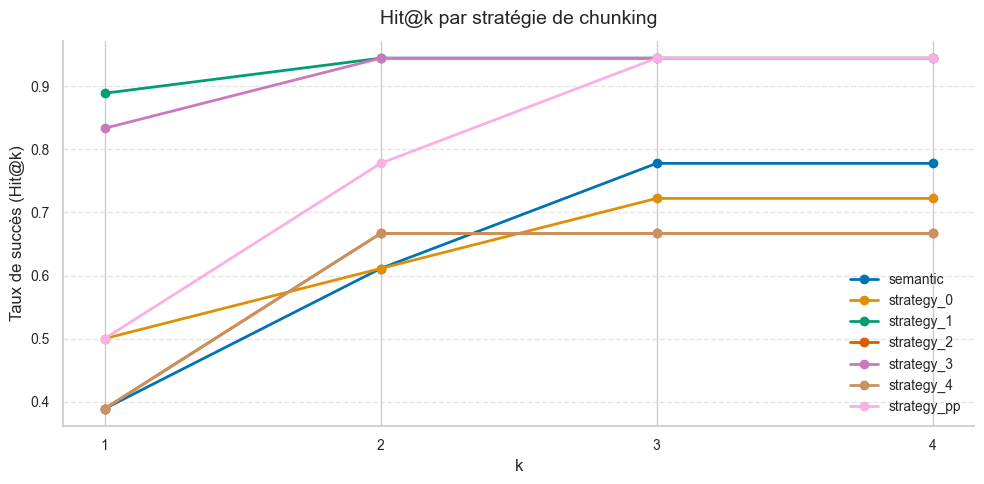

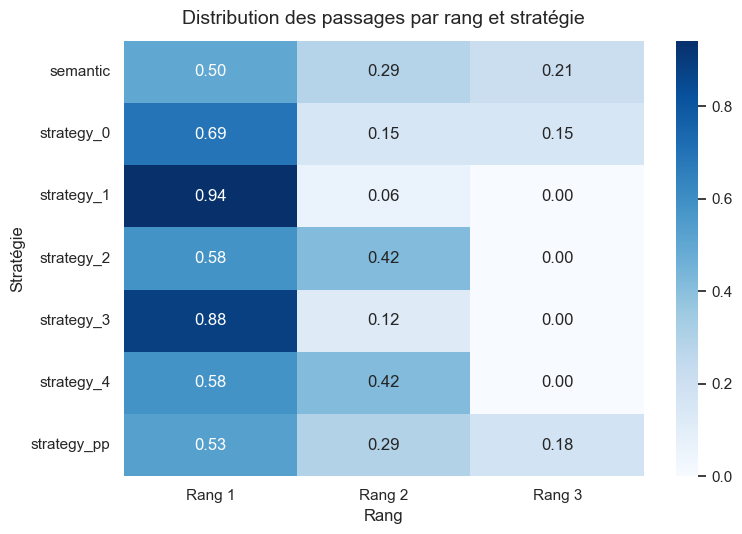

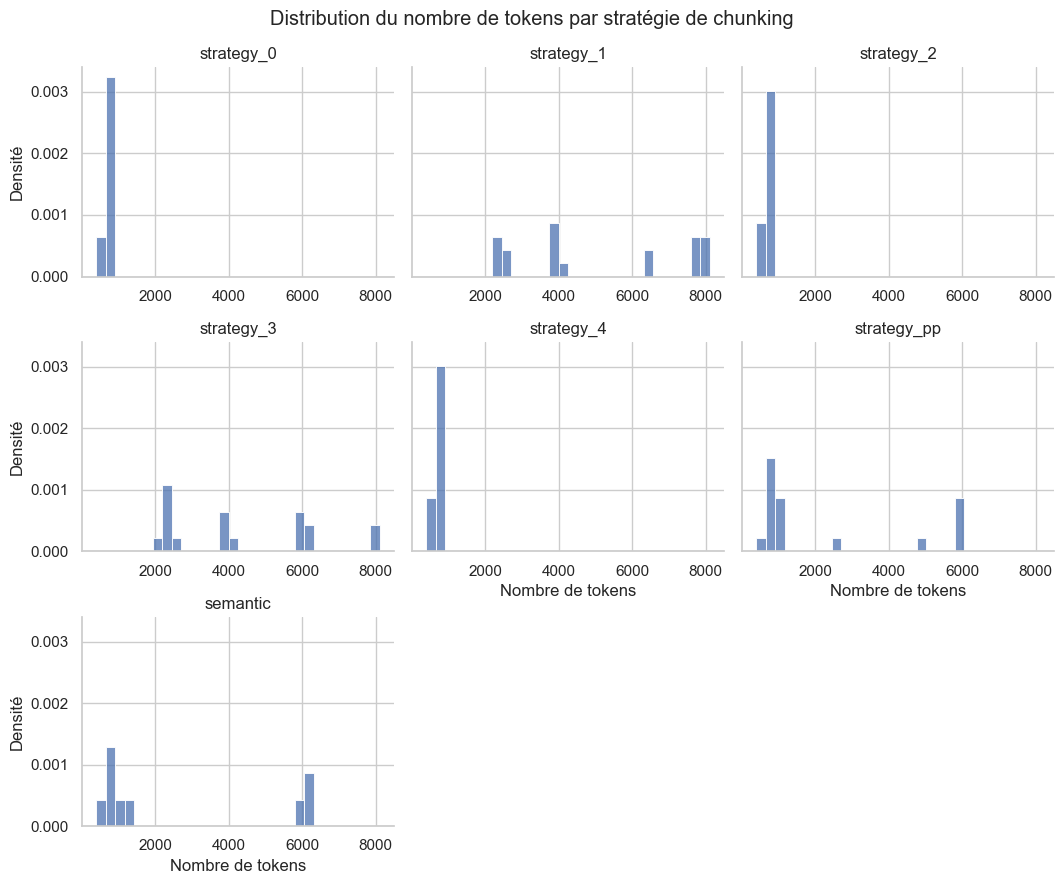

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Charger le JSON
with open("dataset.json", "r") as f:
    data = json.load(f)

# Créer DataFrame
df = pd.DataFrame(data)

# Paramètres
max_k = 4

# Fonctions utilitaires
def reciprocal_rank(rank):
    return 1 / rank if rank and rank > 0 else 0

def get_hits(rank, max_k):
    return [1 if 0 < rank <= k else 0 for k in range(1, max_k + 1)]

# Ajouter colonnes RR, Hit@k
df["RR"] = df["passage_rank"].apply(reciprocal_rank)
for k in range(1, max_k + 1):
    df[f"Hit@{k}"] = df["passage_rank"].apply(lambda r: 1 if r and 0 < r <= k else 0)

# ==== MRR & Hit@k par stratégie ====
grouped = df.groupby("chunking_strategy")
mrr_by_strategy = grouped["RR"].mean()
hitk_by_strategy = grouped[[f"Hit@{k}" for k in range(1, max_k + 1)]].mean()

print("\n=== Mean Reciprocal Rank (MRR) par stratégie ===")
print(mrr_by_strategy)

print("\n=== Hit@k par stratégie ===")
print(hitk_by_strategy)

# ==== Courbes Hit@k ====
# Appliquer un thème épuré
sns.set_theme(style="whitegrid")  # ou "ticks" pour un style académique

# Palette claire adaptée aux daltoniens
palette = sns.color_palette("colorblind", n_colors=len(hitk_by_strategy))

# Création de la figure
plt.figure(figsize=(10, 5))

# Tracer chaque stratégie
for i, (strategy, values) in enumerate(hitk_by_strategy.iterrows()):
    plt.plot(
        range(1, max_k + 1), values.values, marker="o",
        label=strategy, linewidth=2, markersize=6, color=palette[i]
    )

# Personnalisation
plt.title("Hit@k par stratégie de chunking", fontsize=14, pad=12)
plt.xlabel("k", fontsize=12)
plt.ylabel("Taux de succès (Hit@k)", fontsize=12)
plt.xticks(range(1, max_k + 1), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="", frameon=False, fontsize=10)
sns.despine()  # supprime les bordures

plt.tight_layout()
plt.savefig("hit_at_k_clean.png", dpi=300)
plt.show()
# ==== Heatmap de position (par stratégie) ====
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Paramètres
max_rank = 3  # Rangs 1 à 3

# Construction du tableau stratégique
strategies = df["chunking_strategy"].unique()
strategies.sort()  # optionnel, pour ordre alphabétique
data = []

for strategy in strategies:
    subset = df[df["chunking_strategy"] == strategy]
    ranks = subset["passage_rank"].dropna()
    counts = Counter(r for r in ranks if r > 0)
    total = sum(counts.values())
    row = []
    for i in range(1, max_rank + 1):
        freq = counts.get(i, 0) / total if total > 0 else 0
        row.append(freq)
    data.append(row)

# Conversion en DataFrame
heatmap_df = pd.DataFrame(data, index=strategies, columns=[f"Rang {i}" for i in range(1, max_rank + 1)])

# Affichage
plt.figure(figsize=(8, len(strategies) * 0.5 + 2))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Distribution des passages par rang et stratégie", fontsize=14, pad=12)
plt.xlabel("Rang")
plt.ylabel("Stratégie")
plt.tight_layout()
plt.savefig("heatmap_strats.png", dpi=300)
plt.show()


import seaborn as sns

# Histogramme du nombre de tokens en entrée par stratégie de chunking
g = sns.displot(
    data=df, x="prompt_tokens", col="chunking_strategy", col_wrap=3,
    bins=30, stat="density", common_norm=False, facet_kws={'sharex': False},
    height=3, aspect=1.2
)
g.set_titles("{col_name}")
g.set_axis_labels("Nombre de tokens", "Densité")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribution du nombre de tokens par stratégie de chunking")

plt.tight_layout()
plt.savefig("token_hist.png", dpi=300)
plt.show()



### Implémentation de l'Oracle (llm-as-judge) -> fonction peu sophistiquée
Etant donnée un passage espéré et une réponse, il fourni des label sur la fidélité de la réponse au passage
$$
\text{Oracle} : \text{question} \times \text{réponse} \times \text{contexte} \rightarrow \{\text{label}\} \times \{\text{justification}\}
$$


In [22]:
import json
from typing import Union
from pathlib import Path
from tqdm import tqdm

def oracle(json_path: str, llm, save_path: str = None) -> list:
    """
    Lit un fichier JSON (liste de QA), évalue chaque réponse avec un LLM,
    et ajoute 'label', 'justification' et 'human_evaluation' à chaque entrée.
    """
    json_path = Path(json_path)
    data = json.loads(json_path.read_text())

    results = []
    for item in tqdm(data, desc="Évaluation des réponses"):
        question = item.get("question", "")
        answer = item.get("answer", "")
        expected_source = item.get("expected_source", "")

        # Prompt de jugement
        prompt = f"""
Tu es un expert chargé d’évaluer une réponse générée par un système de question-réponse.
Ton objectif est de juger si la réponse est correcte au vu du contexte utilisé, et du contexte attendu. Choisis UN SEUL label parmi la liste suivante :
- "correct"
- "partiellement correct"
- "incorrect"

Puis fournis une justification brève (1 à 3 phrases max).
Question :
{question}

Réponse :
{answer}

Contexte attendu :
{expected_source}

Réponds sous la forme JSON (ne préfixe pas avec ```json ni ```).
{{"label": "...", "justification": "..."}}
        """

        try:
            output = llm.invoke(prompt)
            output_str = getattr(output, "content", str(output)).strip()

            # Nettoyage si le LLM a mis des ``` autour (même si on le demande pas)
            if output_str.startswith("```json"):
                output_str = output_str.removeprefix("```json").removesuffix("```").strip()
            elif output_str.startswith("```"):
                output_str = output_str.removeprefix("```").removesuffix("```").strip()

            judgment = json.loads(output_str)
            item.update(judgment)

        except Exception as e:
            item.update({
                "label": "error",
                "justification": f"Erreur d’évaluation : {str(e)}"
            })
            print("⚠️ Prompt LLM retourné :", repr(output))

        # Ajout champ pour évaluation humaine
        item["human_evaluation"] = ""
        results.append(item)

    # Sauvegarde si demandée
    if save_path:
        save_path = Path(save_path)
        save_path.write_text(json.dumps(results, indent=2, ensure_ascii=False))

    return results

In [ ]:
from backend.RagCore.Utils.configManager import ConfigManager


config_manager = ConfigManager()
llm = config_manager.get_llm_provider()
oracle("dataset.json",llm, "judgement.json")

In [2]:
import pandas as pd
import json

# Charger le JSON
with open("judgement.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Convertir en DataFrame
df = pd.DataFrame(data)

# Sauvegarder en Excel
df.to_excel("data.xlsx", index=False)